DATA IMPORT

In [1]:
import numpy as np
import pandas as pd


In [2]:
# 1. Load the dataset
df = pd.read_csv('social_media_engagement_5000.csv')


In [3]:
# 2. Check initial structure & data types
print("Dataset Shape:", df.shape)
print("\nInitial Data Types:\n", df.dtypes)


Dataset Shape: (5000, 19)

Initial Data Types:
 user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
dtype: object


In [4]:
# 3. Convert date column to datetime format
df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y')


In [5]:
# 4. Basic NumPy array operations demonstration
likes_array = np.array(df['likes'].dropna())
print("\n--- NumPy Operations ---")
print("Max Likes (NumPy):", np.max(likes_array))
print("Min Likes (NumPy):", np.min(likes_array))
print("Mean Likes (NumPy):", np.mean(likes_array))
print("Std Deviation Likes (NumPy):", np.std(likes_array))


--- NumPy Operations ---
Max Likes (NumPy): 19998.0
Min Likes (NumPy): 10.0
Mean Likes (NumPy): 10107.043711340206
Std Deviation Likes (NumPy): 5789.222332204696


DATA CLEANING

In [6]:
# 1. Detect missing values
print("Missing values before cleaning:\n", df.isnull().sum())


Missing values before cleaning:
 user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [7]:
# 2. Handle missing values
# Numerical imputation using median
for col in ['age', 'likes', 'comments', 'shares']:
  df[col] = df[col].fillna(df[col].median())

# Categorical imputation using mode
for col in ['gender', 'sentiment']:
  df[col] = df[col].fillna(df[col].mode()[0])


In [8]:
# 3. Duplicate handling
duplicates_count = df.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicates_count}")
if duplicates_count > 0:
  df = df.drop_duplicates()


Total Duplicate Rows Found: 0


In [9]:
# 4. Data formatting & standardization
df['gender'] = df['gender'].str.strip().str.capitalize()
df['post_type'] = df['post_type'].str.strip().str.lower()
df['post_category'] = df['post_category'].str.strip().str.lower()
df['sentiment'] = df['sentiment'].str.strip().str.lower()

# Correct unrealistic negative values if present
for num_col in ['likes', 'comments', 'shares', 'impression_count']:
  df[num_col] = np.where(df[num_col] < 0, 0, df[num_col])


In [10]:
# 5. Feature cleaning / extraction
df['hashtag_count'] = df['hashtags'].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) else 0
)

print("\nMissing values after cleaning:\n", df.isnull().sum())


Missing values after cleaning:
 user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
hashtag_count       0
dtype: int64


DATA EXPLORATION USING PANDAS

In [11]:
# View dataset structure
print("Head:\n", df.head(3))
print("Tail:\n", df.tail(3))
print("Columns:", df.columns.tolist())

# Check data types and info
df.info()

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Categorical distributions
print("\nPost Type Counts:\n", df['post_type'].value_counts())
print("\nUnique Countries:", df['country'].unique())
print("Number of Unique Countries:", df['country'].nunique())

# Correlation matrix for numeric fields
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
print("\nCorrelation Matrix:\n", correlation_matrix)

# Groupby summaries
avg_likes_type = df.groupby('post_type')['likes'].mean()
impressions_country = df.groupby('country')['impression_count'].sum()

print("\nAvg Likes by Post Type:\n", avg_likes_type)
print("\nTotal Impressions by Country:\n", impressions_country)

Head:
    user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      mobile  negative  #foodie #travel #love   
1            5963        False      mobile  negative               #fitness   
2          501783        False      tablet  positive                #foodie   

   engagement_rate  hashtag_count  
0         0.190862              3  
1         0.201493

DATA WRANGLING

In [12]:
# 1. Feature Engineering: Calculated engagement score and log transformation
df['calculated_engagement_score'] = (
    df['likes'] + df['comments'] + df['shares']
) / df['impression_count']
df['log_followers'] = np.log1p(df['follower_count'])

# 2. Groupby summaries across multiple dimensions
grouped_summary = df.groupby(
    ['post_type', 'sentiment', 'country']
).agg(
    avg_engagement=('engagement_rate', 'mean'),
    avg_likes=('likes', 'mean'),
    avg_watch_time=('watch_time_sec', 'mean'),
    total_posts=('post_id', 'count'),
)

print(grouped_summary.head(10))

                               avg_engagement     avg_likes  avg_watch_time  \
post_type sentiment country                                                   
image     negative  Australia        0.481270   8006.131579     3534.000000   
                    Brazil           0.410408   7559.350000     4401.200000   
                    Canada           0.336268   8932.130435     4223.826087   
                    France           0.732099  11017.615385     3974.307692   
                    Germany          0.689843  10546.250000     3624.250000   
                    India            0.768403  10152.571429     4275.428571   
                    Japan            1.042187  10578.187500     3384.708333   
                    UAE              1.543479  11695.263158     3738.473684   
                    UK               0.641557   9999.142857     4195.500000   
                    USA              0.509504  10304.176471     4142.294118   

                               total_posts  
post_t

DATA VISUALISATION

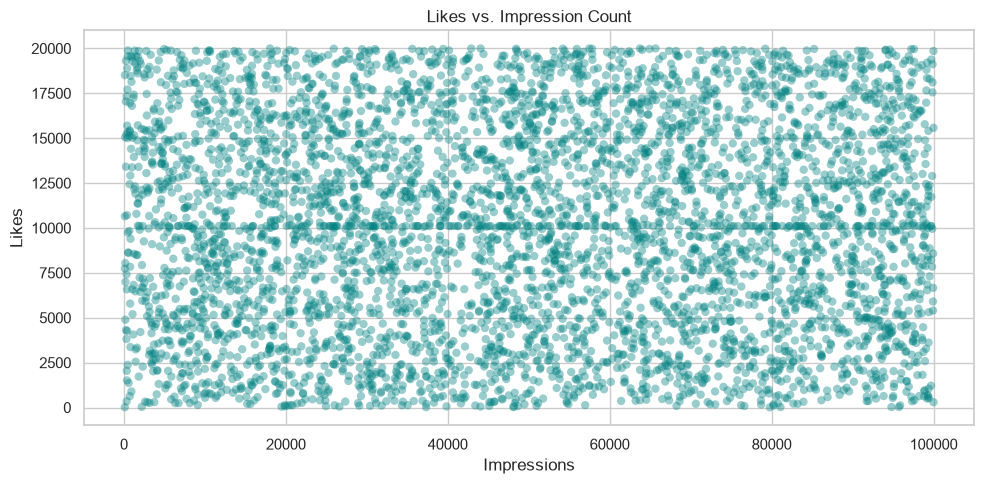

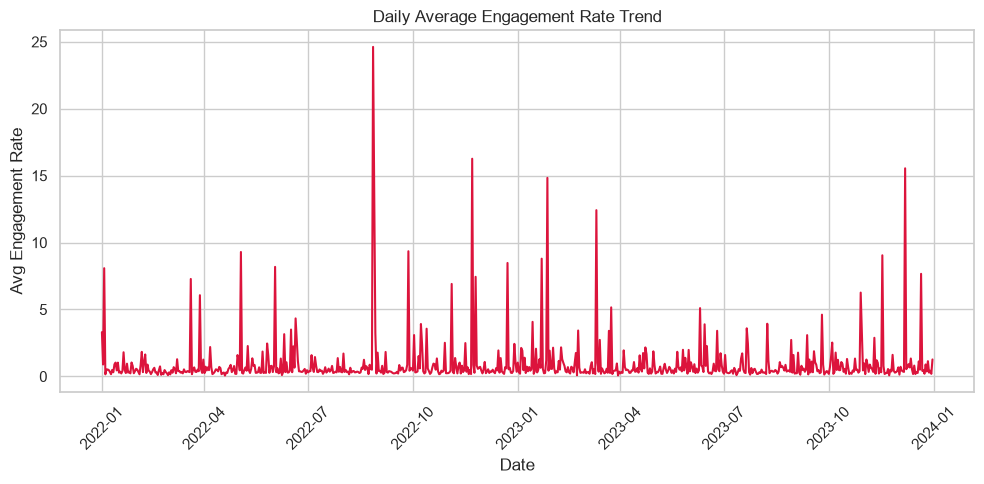

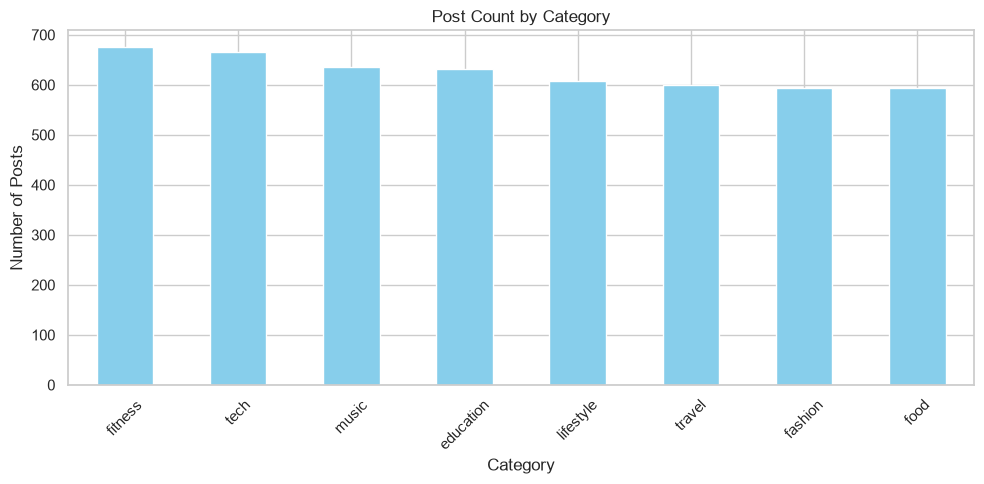

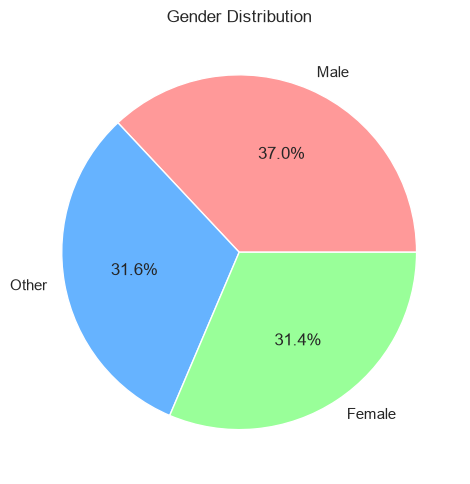

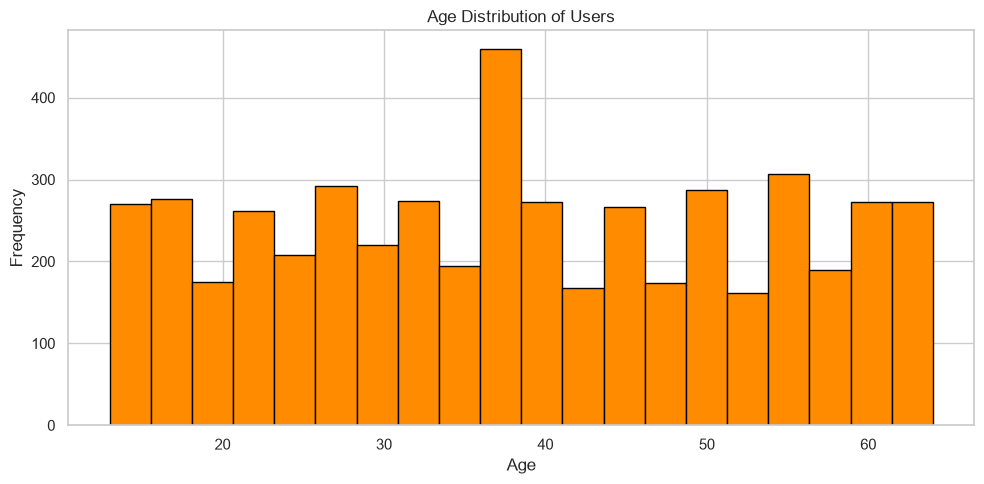

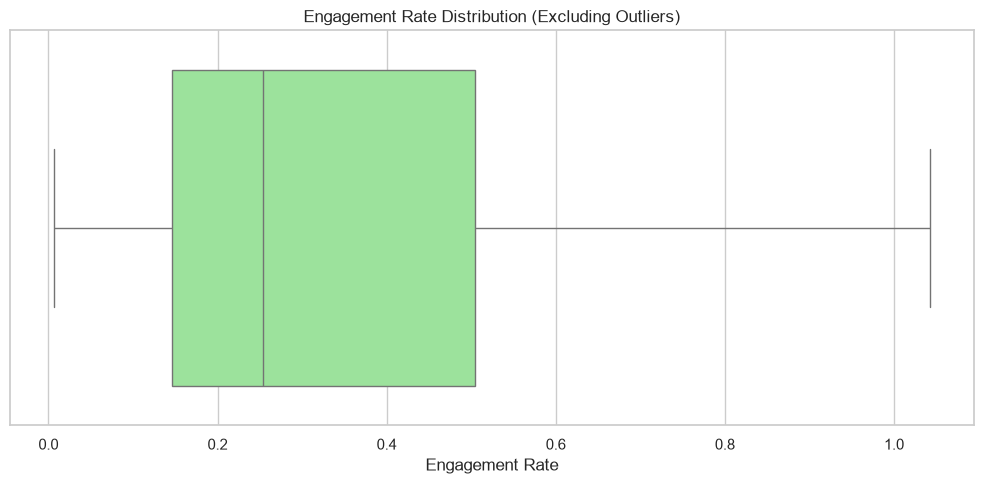

C:\Users\chait\AppData\Local\Temp\ipykernel_25360\2960113662.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='post_type', palette='Set2')


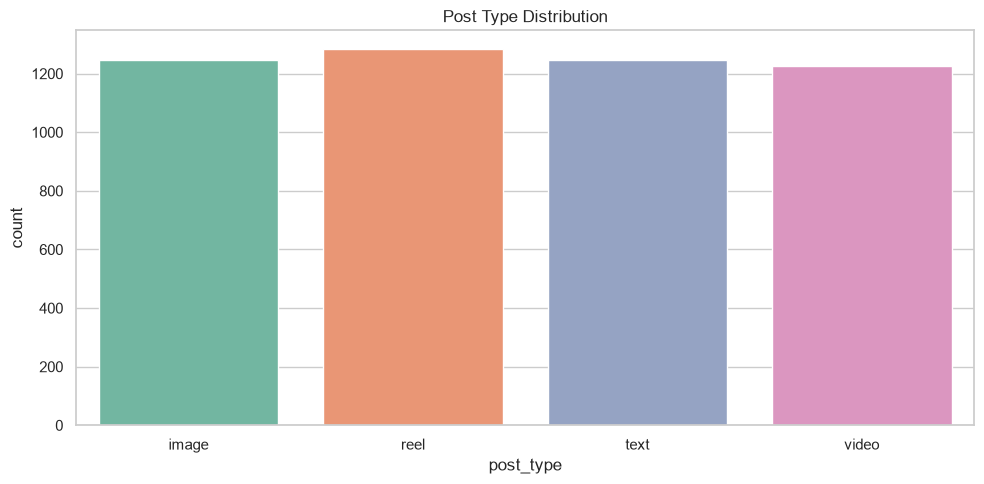

C:\Users\chait\AppData\Local\Temp\ipykernel_25360\2960113662.py:84: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chait\AppData\Local\Temp\ipykernel_25360\2960113662.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


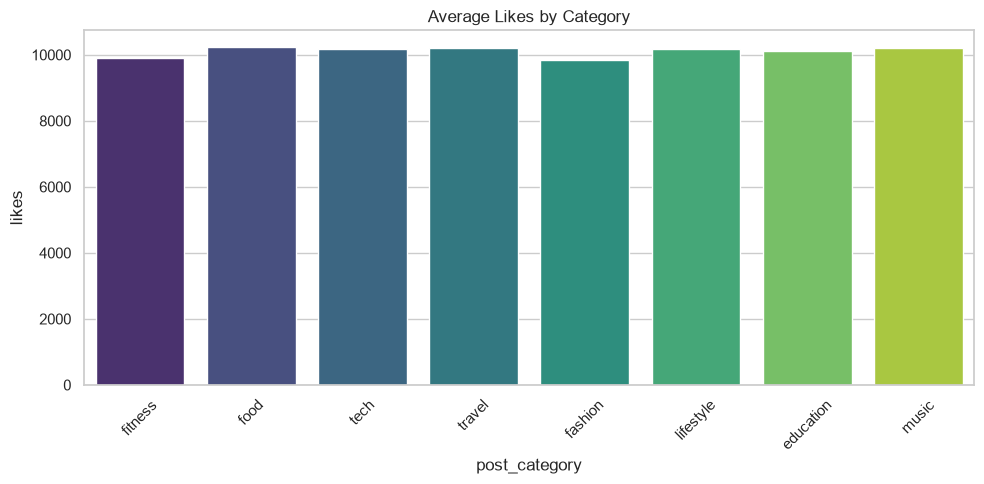

C:\Users\chait\AppData\Local\Temp\ipykernel_25360\2960113662.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


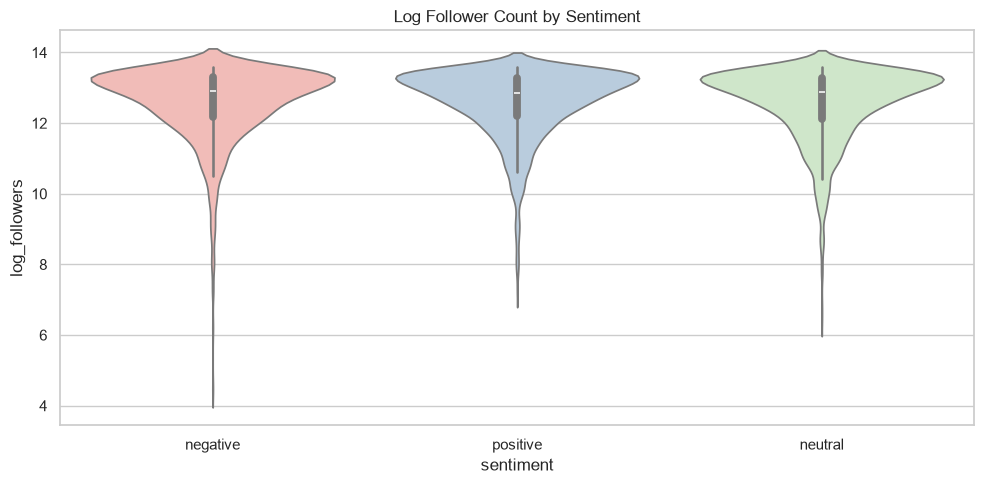

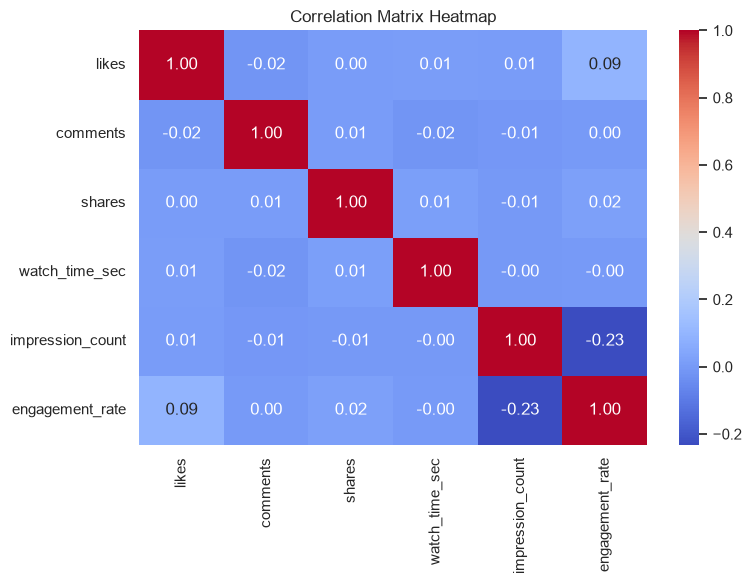

C:\Users\chait\AppData\Local\Temp\ipykernel_25360\2960113662.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


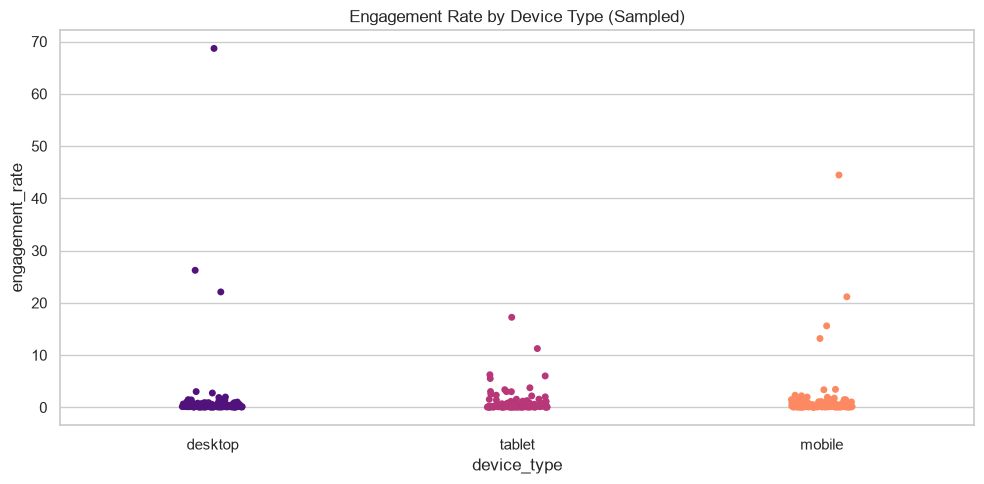

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
# Set visual styles
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# --- MATPLOTLIB PLOTS ---
# Plot 1: Scatter - Likes vs Impressions
plt.figure()
plt.scatter(
    df['impression_count'], df['likes'], alpha=0.4, color='teal', edgecolors='none'
)
plt.title('Likes vs. Impression Count')
plt.xlabel('Impressions')
plt.ylabel('Likes')
plt.tight_layout()
plt.show()

# Plot 2: Line - Daily Engagement Trend
daily_trend = df.groupby('posted_at')['engagement_rate'].mean().reset_index()
plt.figure()
plt.plot(
    daily_trend['posted_at'],
    daily_trend['engagement_rate'],
    color='crimson',
    linewidth=1.5,
)
plt.title('Daily Average Engagement Rate Trend')
plt.xlabel('Date')
plt.ylabel('Avg Engagement Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: Bar - Posts by Category
plt.figure()
df['post_category'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Post Count by Category')
plt.xlabel('Category')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 4: Pie - Gender Distribution
plt.figure()
df['gender'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=['#ff9999', '#66b3ff', '#99ff99']
)
plt.title('Gender Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Plot 5: Histogram - Age Distribution
plt.figure()
plt.hist(df['age'], bins=20, color='darkorange', edgecolor='black')
plt.title('Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot 6: Box - Engagement Rate (Capped for visualization of main density)
plt.figure()
sns.boxplot(x=df['engagement_rate'], color='lightgreen', showfliers=False)
plt.title('Engagement Rate Distribution (Excluding Outliers)')
plt.xlabel('Engagement Rate')
plt.tight_layout()
plt.show()

# --- SEABORN PLOTS ---
# Plot 7: Count Plot - Post Type
plt.figure()
sns.countplot(data=df, x='post_type', palette='Set2')
plt.title('Post Type Distribution')
plt.tight_layout()
plt.show()

# Plot 8: Bar Plot - Avg Likes by Category
plt.figure()
sns.barplot(
    data=df, x='post_category', y='likes', estimator=np.mean, ci=None, palette='viridis'
)
plt.title('Average Likes by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 9: Violin Plot - Followers vs Sentiment
plt.figure()
sns.violinplot(
    data=df, x='sentiment', y='log_followers', palette='Pastel1'
)
plt.title('Log Follower Count by Sentiment')
plt.tight_layout()
plt.show()

# Plot 10: Heatmap - Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[
        [
            'likes',
            'comments',
            'shares',
            'watch_time_sec',
            'impression_count',
            'engagement_rate',
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# Plot 11: Swarm/Strip Plot - Engagement vs Device
plt.figure()
sns.stripplot(
    data=df.sample(500),
    x='device_type',
    y='engagement_rate',
    jitter=True,
    palette='magma',
)
plt.title('Engagement Rate by Device Type (Sampled)')
plt.tight_layout()
plt.show()

# --- PLOTLY INTERACTIVE PLOT ---
# Plot 12: Plotly Scatter Chart
fig = px.scatter(
    df.sample(1000),
    x='impression_count',
    y='likes',
    color='post_type',
    size='comments',
    hover_data=['country', 'post_category'],
    title='Interactive Analysis: Impressions vs Likes by Post Type',
)
fig.show()